### Импорт библиотек

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.optimize as opt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import classification_report

# Часть 2: Бинарная классификация. Случай не разделимых линейно классов

Задача заключалась в определении качества тестов микрочипов (являются ли они бракованными или стандартными)

### Загрузка данных

In [2]:
data2 = pd.read_csv('data/ex2data2.txt', names=['Microchip Test 1', 'Microchip Test 2', 'target'])
data2.head()

,Microchip Test 1,Microchip Test 2,target
0,0.051267,0.69956,1
1,-0.092742,0.68494,1
2,-0.213710,0.69225,1
3,-0.375000,0.50219,1
4,-0.513250,0.46564,1


### Визуализация данных

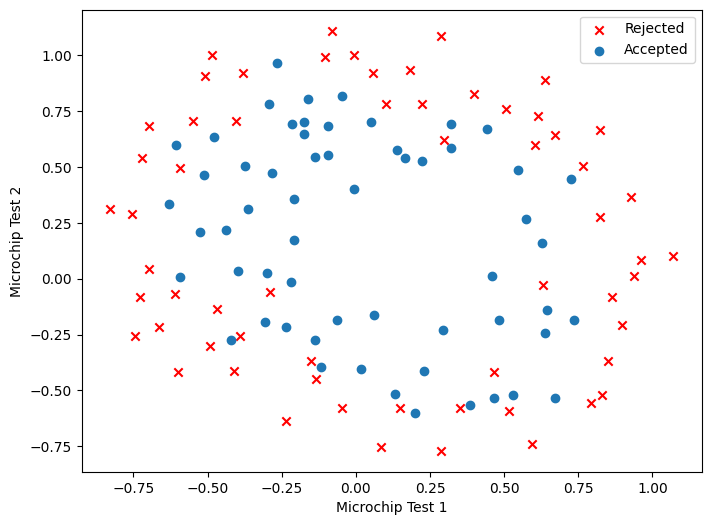

In [3]:
plt.figure(figsize=(8, 6))
plt.scatter(data2[data2['target'] == 0]['Microchip Test 1'], data2[data2['target'] == 0]['Microchip Test 2'], color='red', marker='x', label='Rejected')
plt.scatter(data2[data2['target'] == 1]['Microchip Test 1'], data2[data2['target'] == 1]['Microchip Test 2'], marker='o', label='Accepted')
plt.legend()
plt.xlabel('Microchip Test 1')
plt.ylabel('Microchip Test 2')
plt.show()

### Преобразование данных

In [4]:
poly = PolynomialFeatures(6)
X = poly.fit_transform(data2.iloc[:, :-1])
y = (data2.iloc[:, -1].values).reshape(-1, 1)
theta = np.zeros(X.shape[1])

### Определение сигмоиды

In [5]:
def sigmoid(z: float) -> float:
    return 1 / (1 + np.exp(-z))

### Функция стоимости

In [6]:
def costFuncR(theta: np.ndarray, X: np.ndarray, y: np.ndarray, lam: float) -> float:
    h = sigmoid(X.dot(theta))
    regularization = (lam / (2*len(y))) * np.sum(theta[1:]**2)
    J = -(1/len(y)) * np.sum(np.log(h) @ y + np.log(1-h) @ (1-y)) + regularization
    return J

print(f'Cost at initial theta: {costFuncR(theta, X, y, 1)}')

Cost at initial theta: 0.6931471805599454


### Градиент функции стоимости

In [7]:
def gradientFuncR(theta: np.ndarray, X: np.ndarray, y: np.ndarray, lam: float) -> np.ndarray:
    y = y.reshape(-1, 1)
    theta = theta.reshape(-1, 1)
    h = sigmoid(X @ theta)
    grad = (1/len(y)) * X.T @ (h-y)
    grad[1:] = grad[1:] + lam/len(y) * theta[1:]
    return grad.flatten()

print(f'Gradient at initial theta: {gradientFuncR(theta, X, y, 1)}')

Gradient at initial theta: [8.47457627e-03 1.87880932e-02 7.77711864e-05 5.03446395e-02
 1.15013308e-02 3.76648474e-02 1.83559872e-02 7.32393391e-03
 8.19244468e-03 2.34764889e-02 3.93486234e-02 2.23923907e-03
 1.28600503e-02 3.09593720e-03 3.93028171e-02 1.99707467e-02
 4.32983232e-03 3.38643902e-03 5.83822078e-03 4.47629067e-03
 3.10079849e-02 3.10312442e-02 1.09740238e-03 6.31570797e-03
 4.08503006e-04 7.26504316e-03 1.37646175e-03 3.87936363e-02]


### Оптимизация с различной регуляризацией

In [8]:
def getOptimizedTheta(X: np.ndarray, y: np.ndarray, lam: float) -> np.ndarray:
    result = opt.fmin_tnc(
        func = costFuncR,
        x0 = theta, fprime = gradientFuncR,
        args = (X, y, lam))
    return result[0]

In [9]:
optimized_theta_0 = getOptimizedTheta(X, y, 0)
optimized_theta_1 = getOptimizedTheta(X, y, 1)
optimized_theta_100 = getOptimizedTheta(X, y, 100)

  NIT   NF   F                       GTG
    0    1  6.931471805599454E-01   1.28006529E-02
tnc: stepmx = 1000
    1    7  3.769296573399976E-01   2.82102145E-03
    2   11  3.576202758676167E-01   1.61492713E-04
tnc: fscale = 78.6907
    3   20  3.264291907591625E-01   2.85471694E-05
    4   24  3.195276221204594E-01   4.22036811E-05
    5   35  3.092872531392876E-01   3.63291668E-05
    6   48  3.000708653595780E-01   8.61851486E-05
    7   51  2.983667240563796E-01   9.05680484E-06
    8   63  2.908042455948802E-01   9.34070584E-06
    9   77  2.841745116865440E-01   6.38701349E-06
   10   88  2.821221073118561E-01   7.50849919E-07
   11  101  2.795991282043679E-01   1.49377211E-06
   12  116  2.748859135126467E-01   3.68347679E-06
   13  121  2.737628560438246E-01   1.91881972E-06
   14  127  2.734776889340642E-01   1.64808493E-07
tnc: fscale = 2463.26
   15  136  2.732333694187921E-01   1.97826039E-07
   16  148  2.719313869592539E-01   4.77862579E-07
   17  160  2.712207082316528

### Предсказания

In [10]:
def predict(X: np.ndarray, theta: np.ndarray) -> float:
    return [1 if x >= 0.5 else 0 for x in sigmoid(X @ theta)]

In [11]:
predictions = [predict(X, t) for t in [optimized_theta_0, optimized_theta_1, optimized_theta_100]]
print(f'Lambda = 0: {classification_report(predictions[0], y)}\n{"-"*80}')
print(f'Lambda = 1: {classification_report(predictions[1], y)}\n{"-"*80}')
print(f'Lambda = 100: {classification_report(predictions[2], y)}\n{"-"*80}')

Lambda = 0:               precision    recall  f1-score   support

           0       0.83      0.89      0.86        56
           1       0.90      0.84      0.87        62

    accuracy                           0.86       118
   macro avg       0.86      0.87      0.86       118
weighted avg       0.87      0.86      0.86       118

--------------------------------------------------------------------------------
Lambda = 1:               precision    recall  f1-score   support

           0       0.75      0.90      0.82        50
           1       0.91      0.78      0.84        68

    accuracy                           0.83       118
   macro avg       0.83      0.84      0.83       118
weighted avg       0.84      0.83      0.83       118

--------------------------------------------------------------------------------
Lambda = 100:               precision    recall  f1-score   support

           0       0.75      0.59      0.66        76
           1       0.47      0.64    

### Визуализация границ решения

/home/alexcawl/VsCodeProjects/SUSU.PE/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/tmp/ipykernel_146036/3133580478.py:2: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
/tmp/ipykernel_146036/3060601837.py:30: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(xx1, xx2, Z0, levels=[0.5], colors='purple', linewidths=2, linestyles='solid', label='λ = 0')
/tmp/ipykernel_146036/3060601837.py:33: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(xx1, xx2, Z1, levels=[0.5], colors='blue', linewidths=2, linestyles='dashed', label='λ = 1')
/tmp/ipykernel_146036/3060601837.py:36: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(xx1, xx2, Z100, levels=[0.5], colors='orange', linewidths=2, linestyles='dotted', label='λ = 100')


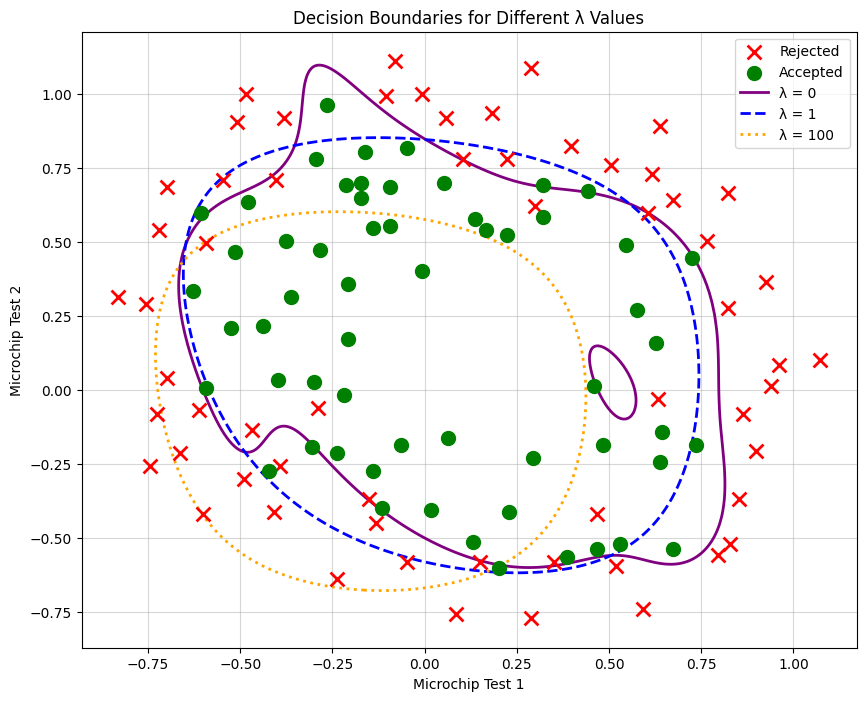

In [12]:
# Создаем сетку точек
from matplotlib.lines import Line2D


x1_min, x1_max = data2['Microchip Test 1'].min() - 0.1, data2['Microchip Test 1'].max() + 0.1
x2_min, x2_max = data2['Microchip Test 2'].min() - 0.1, data2['Microchip Test 2'].max() + 0.1

xx1, xx2 = np.meshgrid(
    np.linspace(x1_min, x1_max, 300),
    np.linspace(x2_min, x2_max, 300)
)

# Преобразуем сетку в полиномиальные признаки
grid_points = np.c_[xx1.ravel(), xx2.ravel()]
grid_poly = poly.transform(grid_points)

# Один график со всеми границами
plt.figure(figsize=(10, 8))

# Рисуем точки данных
plt.scatter(data2[data2['target'] == 0]['Microchip Test 1'],
            data2[data2['target'] == 0]['Microchip Test 2'],
            color='red', marker='x', label='Rejected', s=100, linewidths=2, zorder=5)
plt.scatter(data2[data2['target'] == 1]['Microchip Test 1'],
            data2[data2['target'] == 1]['Microchip Test 2'],
            color="green", marker='o', label='Accepted', s=100, zorder=5)

# Добавляем границы для разных lambda
Z0 = sigmoid(grid_poly @ optimized_theta_0).reshape(xx1.shape)
plt.contour(xx1, xx2, Z0, levels=[0.5], colors='purple', linewidths=2, linestyles='solid', label='λ = 0')

Z1 = sigmoid(grid_poly @ optimized_theta_1).reshape(xx1.shape)
plt.contour(xx1, xx2, Z1, levels=[0.5], colors='blue', linewidths=2, linestyles='dashed', label='λ = 1')

Z100 = sigmoid(grid_poly @ optimized_theta_100).reshape(xx1.shape)
plt.contour(xx1, xx2, Z100, levels=[0.5], colors='orange', linewidths=2, linestyles='dotted', label='λ = 100')

handles, labels = plt.gca().get_legend_handles_labels()
handles.extend([
    Line2D([0], [0], color='purple', linewidth=2, linestyle='solid'),
    Line2D([0], [0], color='blue', linewidth=2, linestyle='dashed'),
    Line2D([0], [0], color='orange', linewidth=2, linestyle='dotted')
])
labels.extend(['λ = 0', 'λ = 1', 'λ = 100'])

plt.xlabel('Microchip Test 1')
plt.ylabel('Microchip Test 2')
plt.title('Decision Boundaries for Different λ Values')
plt.legend(handles, labels)
plt.grid(True, alpha=0.5)
plt.show()